# Myelin Maps Group Statistical Analysis

In [3]:
# Package Installation:
!pip install nilearn seaborn statsmodels surfplot
!pip install neuromaps
# Standard Library:
import os
import re
from pathlib import Path
from collections import defaultdict

# Numerical Computing & Data Handling:
import numpy as np
import pandas as pd

# Neuroimaging:
import nibabel as nib

from nilearn.datasets import fetch_atlas_schaefer_2018
from nilearn.maskers import NiftiLabelsMasker

from neuromaps import datasets, images, nulls
from neuromaps.datasets import fetch_fslr

# Statistics:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# Visualization:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from surfplot import Plot

# Utilities:
from tqdm import tqdm

# Warning Suppression Utility:
import sys
import contextlib
@contextlib.contextmanager
def suppress_vtk_warnings():
    devnull = open(os.devnull, 'w')
    old_stderr = os.dup(2)
    os.dup2(devnull.fileno(), 2)
    try:
        yield
    finally:
        os.dup2(old_stderr, 2)
        devnull.close()

## Create Network Directory

In [4]:
# Load Schaefer 2018 atlas data (300 ROIs, 7 networks, 2 mm resolution):
atlas = fetch_atlas_schaefer_2018(n_rois=300, yeo_networks=7, resolution_mm=2)

# Define atlas image filepath:
atlas_path = "../../../templateflow/tpl-MNI152NLin2009cAsym/tpl-MNI152NLin2009cAsym_res-02_atlas-Schaefer2018_desc-300Parcels7Networks_dseg.nii.gz"

# Load atlas data:
atlas_img = nib.load(atlas_path)
atlas_node_data = atlas_img.get_fdata().astype(int)

# Get the corresponding node labels excluding the background:
labels = atlas["labels"][1:] # 300 labels corresponding to 300 nodes.

# Define a dictionary with network abbreviations as keys and network full names as values:
network_map = {
    "Vis": "Visual Network (VIN)",
    "SomMot": "Somatomotor Network (SMN)",
    "DorsAttn": "Dorsal Attention Network (DAN)",
    "SalVentAttn": "Salience / Ventral Attention Network (SAN/VAN)",
    "Limbic": "Limbic Network (LIN)",
    "Cont": "Control / Frontoparietal Network (FPN/CON)",
    "Default": "Default Mode Network (DMN)"
}

# Initialize an empty dictionary to store results:
network_dict = defaultdict(lambda: {"name": None, "indices": [], "LH": [], "RH": []})

# Iterate through the labels in the atlas:
for roi_idx, label in enumerate(labels, start=1):

    # Get the different text parts of the node label:
    parts = label.split("_")

    # Get the hemisphere of the current node label:
    hemi = parts[1]

    # Get the abbreviation name of the network the current node belongs to:
    network = parts[2]

    # Save both the network name and the index of the label: 
    network_dict[network]["name"] = network_map[network]
    network_dict[network]["indices"].append(roi_idx)

    # Save hemisphere information:
    if hemi == "LH":
        network_dict[network]["LH"].append(roi_idx)
    else:
        network_dict[network]["RH"].append(roi_idx)

# Turn the dictionary into a normal one:
network_dict = dict(network_dict)

# Print summary:
for net, info in network_dict.items():
    print("\n========================")
    print(net)
    print(info["name"])
    print("Total ROIs:", len(info["indices"]))
    print("LH ROIs:", len(info["LH"]))
    print("RH ROIs:", len(info["RH"]))

[fetch_atlas_schaefer_2018] Dataset found in /home/jovyan/nilearn_data/schaefer_2018

Vis
Visual Network (VIN)
Total ROIs: 47
LH ROIs: 24
RH ROIs: 23

SomMot
Somatomotor Network (SMN)
Total ROIs: 57
LH ROIs: 29
RH ROIs: 28

DorsAttn
Dorsal Attention Network (DAN)
Total ROIs: 34
LH ROIs: 16
RH ROIs: 18

SalVentAttn
Salience / Ventral Attention Network (SAN/VAN)
Total ROIs: 34
LH ROIs: 16
RH ROIs: 18

Limbic
Limbic Network (LIN)
Total ROIs: 20
LH ROIs: 10
RH ROIs: 10

Cont
Control / Frontoparietal Network (FPN/CON)
Total ROIs: 40
LH ROIs: 17
RH ROIs: 23

Default
Default Mode Network (DMN)
Total ROIs: 68
LH ROIs: 38
RH ROIs: 30


## Load CN and AD Data

In [5]:
# Define metadata path:
metadata_path = "../../../eda/OASIS3_metadata_clean.csv"

# Load metadata file:
metadata = pd.read_csv(metadata_path)

# Keep only relevant columns:
metadata = metadata[["Subject_ID", "DEMENTED", "NORMCOG"]]

# Create lookup by Subject_ID:
metadata = metadata.set_index("Subject_ID")

# Define the directory containing myelin maps:
myelin_dir = Path("../myelin_maps")

# Sort the files by the subject ID:
files = sorted(myelin_dir.glob("sub-*_sT1T2.nii.gz"), key=lambda f: int(re.search(r"sub-OAS(\d+)", f.name).group(1)))

# Initialize empty lists:
normcog_files = []
demented_files = []
unmatched_files = []

# Loop through sorted files:
for f in files:

    # Extract subject ID:
    subject_id = re.search(r"sub-(OAS\d+)", f.name).group(1)
    
    # Check whether subject exists in metadata:
    if subject_id not in metadata.index:
        unmatched_files.append(f)
        continue

    # Get metadata row:
    row = metadata.loc[subject_id]

    # Assign row to the corresponsing clinical group:
    if row["NORMCOG"] == 1:
        normcog_files.append(f)

    if row["DEMENTED"] == 1:
        demented_files.append(f)

# Print summary:
print(f"NORMCOG files: {len(normcog_files)}")
print(f"DEMENTED files: {len(demented_files)}")
print(f"Unmatched files: {len(unmatched_files)}")

NORMCOG files: 685
DEMENTED files: 400
Unmatched files: 92


## Compute Mean CN Myelin Map

In [6]:
# NORMCOG mean myelin map #

# Initialize an empty list to store normcog images:
normcog_data = []

# Iterate through the normcog files:
for f in tqdm(normcog_files, desc="Loading NORMCOG"):

    # Load the current normcog image:
    img = nib.load(f)

    # Append the current normcog image to the list:
    normcog_data.append(img.get_fdata())

# Compute the mean normcog myelin map:
normcog_data = np.stack(normcog_data, axis=0)
normcog_mean = np.nanmean(normcog_data, axis=0)
del normcog_data

# Compute and print 2nd and 98th percentiles of the mean normcog myelin map:
p2, p98 = np.nanpercentile(normcog_mean, [2, 98])
print(f"2nd percentile:  {p2}")
print(f"98th percentile: {p98}")

print("NORMCOG mean shape:", normcog_mean.shape)

Loading NORMCOG: 100%|██████████| 685/685 [00:11<00:00, 58.58it/s]


2nd percentile:  -0.2574123346257894
98th percentile: 0.30098640583271324
NORMCOG mean shape: (97, 115, 97)


## Compute Mean AD Myelin Map

In [7]:
# DEMENTED mean myelin map #

# Initialize an empty list to store demented images:
demented_data = []

# Iterate through the demented files:
for f in tqdm(demented_files, desc="Loading DEMENTED"):

    # Load the current demented image:
    img = nib.load(f)

    # Append the current demented image to the list:
    demented_data.append(img.get_fdata())

# Compute the mean demented myelin map:
demented_data = np.stack(demented_data, axis=0)
demented_mean = np.nanmean(demented_data, axis=0)
del demented_data

# Compute and print 2nd and 98th percentiles of the mean demented myelin map:
p2, p98 = np.nanpercentile(demented_mean, [2, 98])
print(f"2nd percentile:  {p2}")
print(f"98th percentile: {p98}")

print("DEMENTED mean shape:", demented_mean.shape)

Loading DEMENTED: 100%|██████████| 400/400 [00:06<00:00, 60.47it/s]


2nd percentile:  -0.3272446357446828
98th percentile: 0.2687177968773526
DEMENTED mean shape: (97, 115, 97)


## Save Average Myelin Maps

In [8]:
# Use first image as template:
template_img = nib.load(normcog_files[0])

# Create average normcog myelin map image:
mean_normcog_img = nib.Nifti1Image(normcog_mean.astype(np.float32), affine=template_img.affine, header=template_img.header)

# Create average demented myelin map image:
mean_demented_img = nib.Nifti1Image(demented_mean.astype(np.float32), affine=template_img.affine, header=template_img.header)

# Save files:
normcog_output_file = "normcog_mean_myelin.nii.gz"
nib.save(mean_normcog_img , normcog_output_file)

demented_output_file = "demented_mean_myelin.nii.gz"
nib.save(mean_demented_img , demented_output_file)

## Plot Average Myelin Maps

In [9]:
# Define helper function to plot middle slices of a 3D brain volume:
def plot_middle_slices(vol, cmap, title, cbar_title, background=False, vmin=None, vmax=None, save_info=None):

    # Unpack volume dimensions:
    x, y, z = vol.shape

    # Define brain mask file path:
    mask_path = "../../../templateflow/tpl-MNI152NLin2009cAsym/tpl-MNI152NLin2009cAsym_res-02_desc-brain_mask.nii.gz"
    
    # Load brain mask volume:
    mask_img = nib.load(mask_path)
    mask = mask_img.get_fdata()

    # If enabled, compute robust display range using only brain voxels:
    if vmin is None or vmax is None:
        # Obtain non-zero values:
        brain_vals = vol[mask > 0]

        # Compute 2nd percentile:
        p2 = np.percentile(brain_vals, 2)
        vmin = p2

        # Proceed only if background condition is enabled:
        if background:
            # Compute 95th percentile:
            p95 = np.percentile(brain_vals, 95)
            vmin = p95

        # Compute 99.5th percentile:        
        p99_5 = np.percentile(brain_vals, 99.5)
        vmax = p99_5

    # Extract middle axial, coronal and sagittal slices:
    axial = vol[:, :, z // 2]
    coronal = vol[:, y // 2, :]
    sagittal = vol[x // 2, :, :]

    # Extract corresponding mask slices:
    axial_mask = mask[:, :, z // 2]
    coronal_mask = mask[:, y // 2, :]
    sagittal_mask = mask[x // 2, :, :]

    # Mask zero values in axial, coronal and sagittal slices:
    axial = np.ma.masked_where(axial_mask == 0, axial)
    coronal = np.ma.masked_where(coronal_mask == 0, coronal)
    sagittal = np.ma.masked_where(sagittal_mask == 0, sagittal)

    # Create figure with 3 side-by-side subplots:
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # Proceed only if background condition is enabled:
    if background:
        # Define background brain image file path:
        brain_path = "../../../templateflow/tpl-MNI152NLin2009cAsym/tpl-MNI152NLin2009cAsym_res-02_desc-brain_T1w.nii.gz"

        # Load background brain volume:
        brain_img = nib.load(brain_path)
        brain = brain_img.get_fdata()

        # Extract middle axial, coronal and sagittal brain slices:
        brain_axial = brain[:, :, z // 2]
        brain_coronal = brain[:, y // 2, :]
        brain_sagittal = brain[x // 2, :, :]

        # Mask values below p95 in axial, coronal and sagittal slices:
        axial = np.ma.masked_where(axial < p95, axial)
        coronal = np.ma.masked_where(coronal < p95, coronal)
        sagittal = np.ma.masked_where(sagittal < p95, sagittal)

    # Proceed only if background condition is enabled:
    if background:
        # Mask axial brain slice:
        brain_axial = np.ma.masked_where(axial_mask == 0, brain_axial)
        
        # Display axial brain slice:
        axes[0].imshow(brain_axial.T, cmap='gray', origin='lower')

    # Display axial slice:
    axes[0].imshow(axial.T, cmap=cmap, origin='lower', vmin=vmin, vmax=vmax)
    axes[0].set_title('Axial', y=0.95, fontsize=16)
    axes[0].axis('off')

    # Proceed only if background condition is enabled:
    if background:
        # Mask coronal brain slice:
        brain_coronal = np.ma.masked_where(coronal_mask == 0, brain_coronal)
        
        # Display coronal brain slice:
        axes[1].imshow(brain_coronal.T, cmap='gray', origin='lower')
        
    # Display coronal slice:
    axes[1].imshow(coronal.T, cmap=cmap, origin='lower', vmin=vmin, vmax=vmax)
    axes[1].set_title('Coronal', y=0.95, fontsize=16)
    axes[1].axis('off')

    # Proceed only if background condition is enabled:
    if background:
        # Mask sagittal brain slice:
        brain_sagittal = np.ma.masked_where(sagittal_mask == 0, brain_sagittal)
        
        # Display sagittal brain slice:
        axes[2].imshow(brain_sagittal.T, cmap='gray', origin='lower')

    # Display sagittal slice:
    im = axes[2].imshow(sagittal.T, cmap=cmap, origin='lower', vmin=vmin, vmax=vmax)
    axes[2].set_title('Sagittal', y=1, fontsize=16)
    axes[2].axis('off')

    # Set general figure title:
    fig.suptitle(title, fontsize=20, y=1.02)

    # Reduce spacing between subplots:
    plt.subplots_adjust(wspace=-0.1)

    # Create dedicated colorbar axis and place it:
    cax = fig.add_axes([0.92, 0.15, 0.025, 0.7])

    # Define custom colorbar ticks:
    ticks = np.linspace(vmin, vmax, 8)
    cbar = fig.colorbar(im, cax=cax, ticks=ticks)
    
    # Build tick labels:
    tick_labels = [f"{t:.2f}" for t in ticks]
    
    # Modify first and last ticks:
    tick_labels[0] = rf"$\mathbf{{p2}}$ = {ticks[0]:.2f}"
    tick_labels[-1] = rf"$\mathbf{{p98}}$ = {ticks[-1]:.2f}"

    # Proceed only if background condition is enabled:
    if background:
        tick_labels[0] = rf"$\mathbf{{p95}}$ = {ticks[0]:.2f}"
        tick_labels[-1] = rf"$\mathbf{{p99.5}}$ = {ticks[-1]:.2f}"

    # Applu changes:
    cbar.set_ticklabels(tick_labels)

    # Set colorbar label:
    cbar.set_label(cbar_title, fontsize=16, fontweight='bold', labelpad=8)

    # Define colorbar ticks' style:
    cbar.ax.tick_params(labelsize=10, width=1.5, length=6)
    cbar.outline.set_linewidth(1.5)

    # Define output folder:
    output_folder = "Figures/Myelin_Maps"

    # Make sure output folder exists:
    os.makedirs(output_folder, exist_ok=True)

    # Save figure
    fig.savefig(f"{output_folder}/Average_Myelin_Map_{save_info}.svg", dpi=300, bbox_inches="tight")

    # Render the figure:
    plt.show()

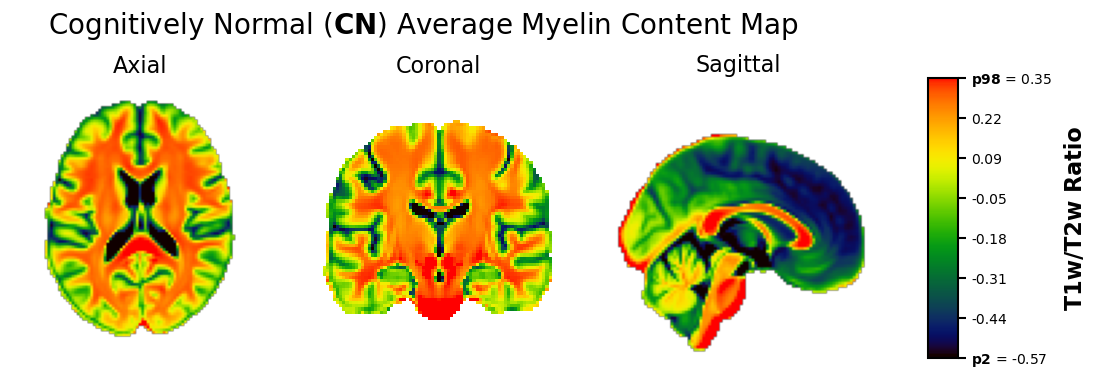

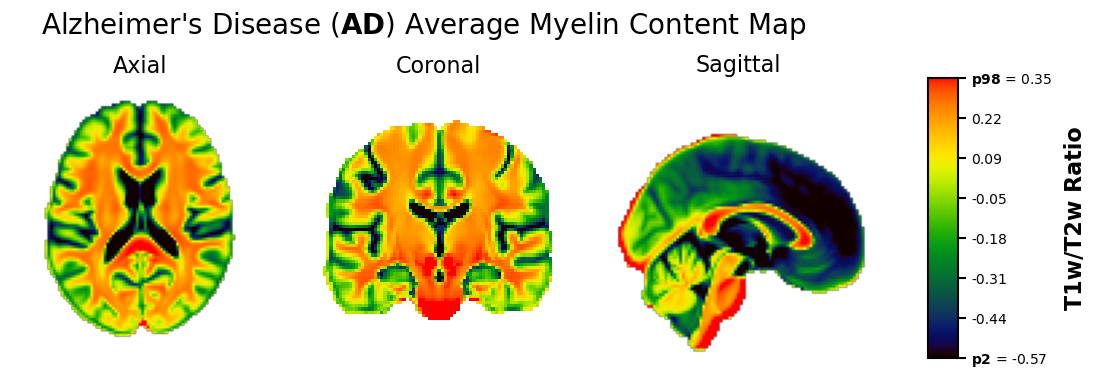

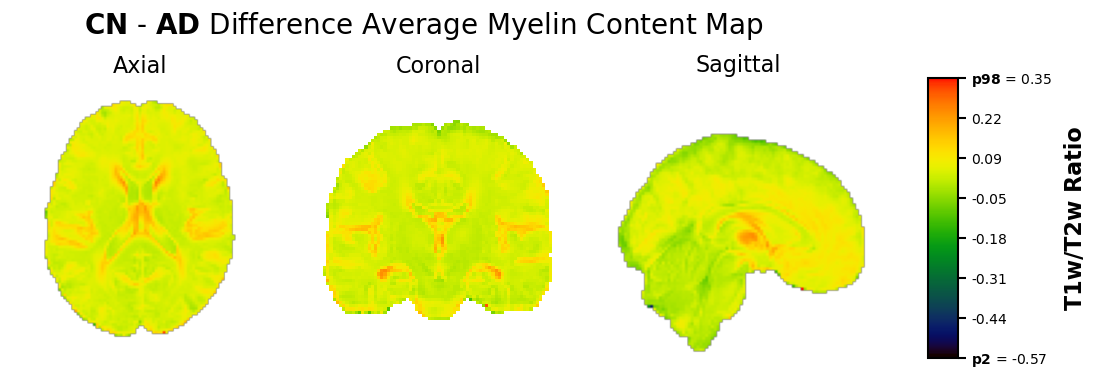

In [10]:
# Load brain colors actc colormap:
actc_colors = np.loadtxt("../../../fsl_colormaps/brain_colours/actc.cmap")

# Create a custom Matplotlib colormap object:
actc_cmap = ListedColormap(actc_colors, name="actc")

# Define brain mask file path:
mask_path = "../../../templateflow/tpl-MNI152NLin2009cAsym/tpl-MNI152NLin2009cAsym_res-02_desc-brain_mask.nii.gz"
    
# Load brain mask volume:
mask_img = nib.load(mask_path)
mask = mask_img.get_fdata()

# Compute global 2 and 98 percentiles for plotting:
vmin = min(np.percentile(normcog_mean[mask > 0], 2), np.percentile(demented_mean[mask > 0], 2))
vmax = max(np.percentile(normcog_mean[mask > 0], 98), np.percentile(demented_mean[mask > 0], 98))

# Call the helper function to plot the mean myelin map for the AD group:
plot_middle_slices(normcog_mean, actc_cmap, title=r"Cognitively Normal ($\mathbf{CN}$) Average Myelin Content Map", cbar_title="T1w/T2w Ratio", vmin=vmin, vmax=vmax, save_info="CN")

# Call the helper function to plot the mean myelin map for the AD group:
plot_middle_slices(demented_mean, actc_cmap, title=r"Alzheimer's Disease ($\mathbf{AD}$) Average Myelin Content Map", cbar_title="T1w/T2w Ratio", vmin=vmin, vmax=vmax, save_info="AD")

# Call the helper function to plot the difference myelin map:
plot_middle_slices(normcog_mean - demented_mean, actc_cmap, title=r"$\mathbf{CN}$ - $\mathbf{AD}$ Difference Average Myelin Content Map", cbar_title="T1w/T2w Ratio", vmin=vmin, vmax=vmax, save_info="Diff")

## Statistical Group Analysis

In [12]:
# Get image shape from first file:
shape = nib.load(normcog_files[0]).shape

# Initialize empty t and p value maps:
t_map = np.zeros(shape, dtype=np.float32)
p_map = np.zeros(shape, dtype=np.float32)

# Iterate through image slices:
for z in tqdm(range(shape[2]), desc="Computing voxelwise Welch t-test"):

    # Stack the current slices of the normcog images:
    norm_slice = np.stack([nib.load(f).dataobj[:, :, z] for f in normcog_files], axis=0)

    # Stack the current slices of the demented images:
    dem_slice = np.stack([nib.load(f).dataobj[:, :, z] for f in demented_files], axis=0)

    # Perform Welch's t-test on the current slice:
    t, p = ttest_ind(norm_slice, dem_slice, axis=0, equal_var=False, nan_policy="omit")

    # Save results
    t_map[:, :, z] = t
    p_map[:, :, z] = p

Computing voxelwise Welch t-test: 100%|██████████| 97/97 [12:58<00:00,  8.02s/it]


In [14]:
# Flatten p-values:
p_flat = p_map.ravel()

# Handle NaN values:
valid_mask = ~np.isnan(p_flat)
p_valid = p_flat[valid_mask]

# Perform Benjamini–Hochberg False Discovery Rate (FDR) correction:
_, p_fdr_valid, _, _ = multipletests(p_valid, alpha=0.05, method="fdr_bh")

# Create full corrected map:
p_fdr_flat = np.full(p_flat.shape, np.nan, dtype=np.float32)
p_fdr_flat[valid_mask] = p_fdr_valid

# Reshape back to image volume:
p_fdr_map = p_fdr_flat.reshape(p_map.shape)

# Binary map of FDR-significant edges:
sig_map = p_fdr_map < 0.05

# Threshold t-value map:
t_thresh_map = np.where(sig_map, t_map, 0)

# Use one of the input images as reference for affine/header
ref_img = nib.load(normcog_files[0])

# Create myelin map thresholded t map image:
t_thresh_img = nib.Nifti1Image(t_thresh_map, affine=template_img.affine, header=template_img.header)

# Save file:
nib.save(t_thresh_img, "CN_vs_AD_t_map.nii.gz")

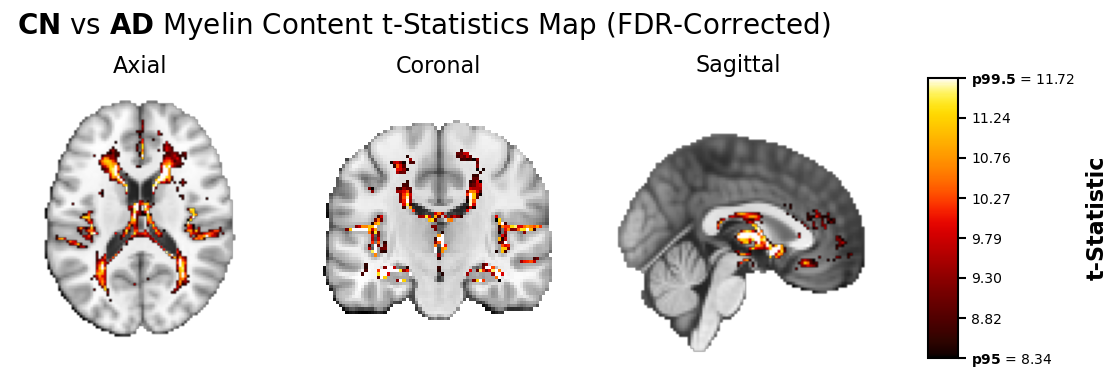

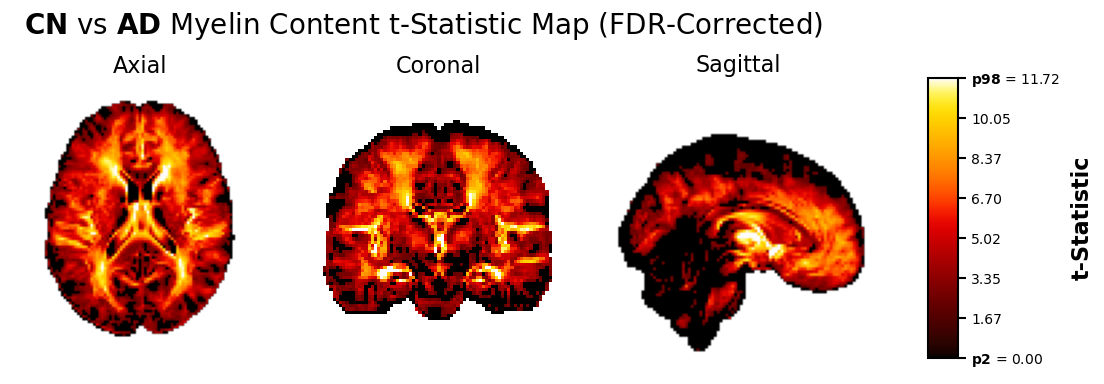

In [15]:
# Load thresholded t-Statistics map:
t_thresh_map_img = nib.load("CN_vs_AD_t_map.nii.gz")
t_thresh_map = t_thresh_map_img.get_fdata()

# Load brain colors actc colormap:
blackbdy_colors = np.loadtxt("../../../fsl_colormaps/brain_colours/blackbdy.cmap")

# Create a custom Matplotlib colormap object:
blackbdy_cmap = ListedColormap(blackbdy_colors, name="blackbdy")

# Call the helper function to plot the mean myelin map for the AD group:
plot_middle_slices(t_thresh_map, blackbdy_cmap, background=True, title=r"$\mathbf{CN}$ vs $\mathbf{AD}$ Myelin Content t-Statistics Map (FDR-Corrected)", cbar_title="t-Statistic", save_info="t-Statistic_Background")

# Call the helper function to plot the mean myelin map for the AD group:
plot_middle_slices(t_thresh_map, blackbdy_cmap, title=r"$\mathbf{CN}$ vs $\mathbf{AD}$ Myelin Content t-Statistic Map (FDR-Corrected)", cbar_title="t-Statistic", save_info="t-Statistic_")

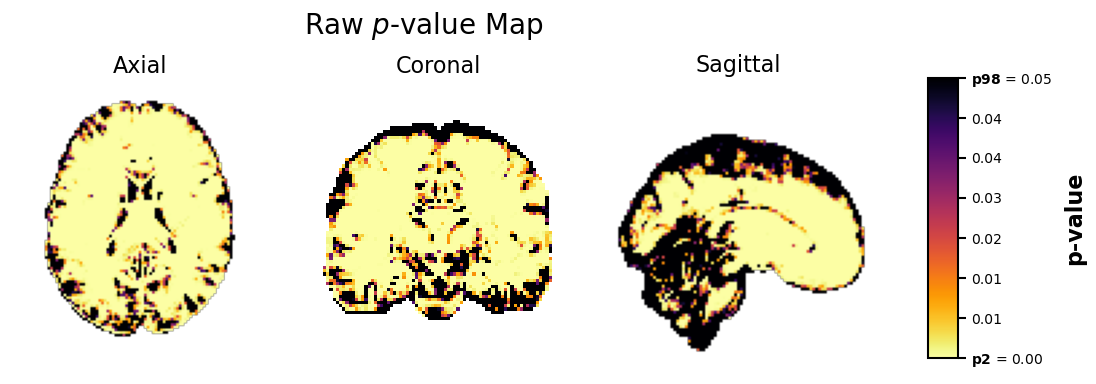

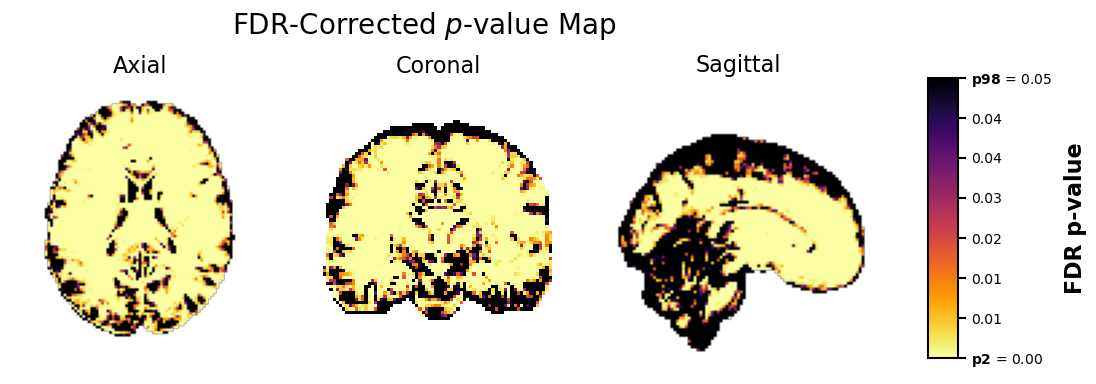

In [16]:
# Cargar un mapa de colores invertido (el '_r' invierte el mapa para que 0 sea brillante y 1 oscuro)
cmap_pvals = plt.get_cmap("inferno_r")

# --- 1. Graficar el mapa de p-valores crudos (Raw p-values) ---
# Mostramos el rango de 0 a 0.05 para centrarnos en lo significativo
plot_middle_slices(
    p_map, 
    cmap=cmap_pvals, 
    title=r"Raw $\mathit{p}$-value Map", 
    cbar_title="p-value", 
    vmin=0.0, 
    vmax=0.05, 
    save_info="raw_p_map"
)

# --- 2. Graficar el mapa de p-valores corregidos por FDR ---
# Mostramos el rango de 0 a 0.05. Todo lo que sea > 0.05 saldrá en negro (no significativo)
plot_middle_slices(
    p_fdr_map, 
    cmap=cmap_pvals, 
    title=r"FDR-Corrected $\mathit{p}$-value Map", 
    cbar_title="FDR p-value", 
    vmin=0.0, 
    vmax=0.05, 
    save_info="fdr_p_map"
)

## Create Surface Maps

In [17]:
# Load myelin features .csv file:
df_myelin = pd.read_csv("myelin_features_all_subjects_filtered.csv")

# Identify columns:
subject_col = df_myelin.columns[0]
group_col = df_myelin.columns[-2]
age_col = df_myelin.columns[-1]

# Define feature myelin columns:
feature_cols = df_myelin.columns[1:-2]

# Compute group-wise means:
myelin_group_means = df_myelin.groupby(group_col)[feature_cols].mean()

# Show results:
myelin_group_means

,7Networks_LH_Vis_1,7Networks_LH_Vis_2,7Networks_LH_Vis_3,7Networks_LH_Vis_4,7Networks_LH_Vis_5,7Networks_LH_Vis_6,7Networks_LH_Vis_7,7Networks_LH_Vis_8,7Networks_LH_Vis_9,7Networks_LH_Vis_10,...,7Networks_RH_Default_PFCdPFCm_7,7Networks_RH_Default_PFCdPFCm_8,7Networks_RH_Default_PFCdPFCm_9,7Networks_RH_Default_PFCdPFCm_10,7Networks_RH_Default_pCunPCC_1,7Networks_RH_Default_pCunPCC_2,7Networks_RH_Default_pCunPCC_3,7Networks_RH_Default_pCunPCC_4,7Networks_RH_Default_pCunPCC_5,7Networks_RH_Default_pCunPCC_6
group,,,,,,,,,,,,,,,,,,,,,
DEMENTED,-0.012457,-0.021886,0.031550,0.018361,0.045832,0.070377,-0.110680,0.086317,-0.070408,0.012871,...,-0.081817,-0.157662,-0.089357,0.004686,0.025259,-0.061943,0.076735,0.019241,0.018164,-0.057038
NORMCOG,0.014126,0.012183,0.058518,0.048605,0.080560,0.088688,-0.072756,0.102300,-0.041850,0.045944,...,-0.033110,-0.097715,-0.039538,0.038414,0.059466,-0.011805,0.105635,0.052685,0.058406,-0.016918


In [18]:
# Import the Schaeffer / Yeo 7 network and 300 parcel atlas:
yeo7_img = nib.load("Atlas/Schaefer2018_300Parcels_7Networks_order.dlabel.nii")
yeo7_data = yeo7_img.get_fdata().squeeze()

# Print the amount of vertices of the parcellation file:
print('Vertices of the parcellation file:', len(yeo7_data))

# Helper function to build Schaeffer 300 node / Yeo 7 network surface map of the defined metric:
def build_surface_map(labels, network_dict, values):
    # Initialize an empty vector with the size of the atlas:
    surface_map = np.zeros_like(labels, dtype=float)
    
    # Iterate over the node values and assign them to the surface map:
    for idx, value in enumerate(values, start=1):

        # Build a mask over the labels data where values match the current node's label:
        mask = np.isin(labels, idx)

        # Assign the corresponding value:
        surface_map[mask] = value

    return surface_map

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


Vertices of the parcellation file: 64984


In [19]:
# Prepare mean myelin values for both clinical groups of NORMCOG and DEMENTED:
mean_myelin_normcog_values = list(myelin_group_means.iloc[1])
mean_myelin_demented_values = list(myelin_group_means.iloc[0])
mean_myelin_difference_values = list(myelin_group_means.iloc[1] - myelin_group_means.iloc[0])

# Compute global 2 and 98 percentiles for plotting:
vmin = min(np.percentile(mean_myelin_normcog_values, 2), np.percentile(mean_myelin_demented_values, 2))
vmax = max(np.percentile(mean_myelin_normcog_values, 98), np.percentile(mean_myelin_demented_values, 98))

# Build mean myelin value maps for both clinical groups of NORMCOG and DEMENTED, the difference case:
mean_myelin_normcog_map = build_surface_map(yeo7_data, network_dict, mean_myelin_normcog_values)
mean_myelin_demented_map = build_surface_map(yeo7_data, network_dict, mean_myelin_demented_values)
mean_myelin_difference_map = build_surface_map(yeo7_data, network_dict, mean_myelin_difference_values)

In [20]:
# Helper function to create surface brain plots:
def surface_brain_plot(scalar_map, title=None, cmap='YlOrRd_r', cbar_label=None, vmin=None, vmax=None):

    # Proceed if plotting limits are not defined:
    if vmin is None or vmax is None:
        # Compute 2nd and 98th percentiles:
        p2 = np.nanpercentile(scalar_map, 2)
        vmin = p2

        p98 = np.nanpercentile(scalar_map, 98)
        vmax = p98
        
    # Fetch FreeSurfer-like fsLR surface meshes:
    surfaces = fetch_fslr()
    
    # Extract left and right inflated cortical surfaces for plotting geometry:
    lh, rh = surfaces['inflated']

    # Extract sulcal depth maps (used as anatomical background shading):
    sulc_lh, sulc_rh = surfaces['sulc']

    # Initialize a Surfplot object with left and right hemisphere surfaces:
    p = Plot(surf_lh=lh, surf_rh=rh)    

    # Add the main scalar data layer:
    p.add_layer(scalar_map, cmap=cmap, color_range=(vmin, vmax), cbar_label=cbar_label)

    # Build the final figure object from all added layers:
    fig = p.build()

    # Set figure title:
    if title:
        fig.suptitle(title, fontsize=16)

    return fig

In [ ]:
# Define output folder:
output_folder = "Figures/Myelin_Maps"

# Make sure output folder exists:
os.makedirs(output_folder, exist_ok=True)

# Create figures without warnings:
with suppress_vtk_warnings():
    ### MEAN FC ###
    
    # Figure 1: Cognitively Normal (CN)
    fig1 = surface_brain_plot(mean_myelin_normcog_map, title=r"Cognitively Normal ($\mathbf{CN}$) Average Myelin Content Map", cmap=actc_cmap, cbar_label='T1w/T2w Ratio', vmin=vmin, vmax=vmax)
    fig1.savefig(f"{output_folder}/Average_Myelin_surface_brain_plot_CN.svg", dpi=300, bbox_inches="tight")
    fig1.show()

    # Figure 2: Alzheimer's Disease (AD)
    fig2 = surface_brain_plot(mean_myelin_demented_map, title=r"Alzheimer's Disease ($\mathbf{AD}$) Average Myelin Content Map", cmap=actc_cmap, cbar_label='T1w/T2w Ratio', vmin=vmin, vmax=vmax)
    fig2.savefig(f"{output_folder}/Average_Myelin_surface_brain_plot_AD.svg", dpi=300, bbox_inches="tight")
    fig2.show()

    # Figure 3: Difference
    fig3 = surface_brain_plot(mean_myelin_difference_map, title=r"$\mathbf{CN}$ - $\mathbf{AD}$ Difference Average Myelin Content Map", cmap=actc_cmap, cbar_label='T1w/T2w Ratio', vmin=vmin, vmax=vmax)
    fig3.savefig(f"{output_folder}/Average_Myelin_surface_brain_plot_Diff.svg", dpi=300, bbox_inches="tight")
    fig3.show()